In [60]:
import sys
from pathlib import Path

# Locate project root (the dir that contains both 'core/' and 'model-building/')
_root = Path.cwd().resolve()
for _ in range(5):
    if (_root / "core").is_dir() and (_root / "model-building").is_dir():
        break
    _root = _root.parent

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
if str(_root / "model-building") not in sys.path:
    sys.path.insert(0, str(_root / "model-building"))

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import wandb

from core.constants import FOOD_INFLATION_CSV_FILENAME, WANDB_MODEL_NAME, WANDB_PROJECT
from core.predictor import FoodInflationPredictor
from utils.data import load_food_inflation_data, train_val_test_split
from utils.plots import plot_country_inflation, plot_pred_vs_real, plot_country_test_predictions, plot_country_forecast
from utils.quality_gate import run_quality_gate
from utils.registry import register_model
from utils.training import train_and_evaluate

## Carga y exploración del dataset

In [61]:
df = load_food_inflation_data(FOOD_INFLATION_CSV_FILENAME)
df.head(10)

,country,country_name,date,inflation
0,ABW,Aruba,2001-01-01,4.287808
1,ABW,Aruba,2001-02-01,4.425079
2,ABW,Aruba,2001-03-01,4.030159
3,ABW,Aruba,2001-04-01,4.056972
4,ABW,Aruba,2001-05-01,3.753138
5,ABW,Aruba,2001-06-01,4.196718
6,ABW,Aruba,2001-07-01,3.672698
7,ABW,Aruba,2001-08-01,3.873451
8,ABW,Aruba,2001-09-01,3.870990
9,ABW,Aruba,2001-10-01,4.073828


In [62]:
df.describe()

,date,inflation
count,59839,59839.000000
mean,2013-02-21 08:26:29.224418816,45.477730
min,2001-01-01 00:00:00,-24.982988
25%,2007-02-01 00:00:00,1.497504
50%,2013-03-01 00:00:00,4.091723
75%,2019-04-01 00:00:00,8.585937
max,2025-06-01 00:00:00,371537.503265
std,NaN,2864.567081


In [63]:
print(f"Países únicos:        {df['country'].nunique()}")
print(f"Rango de fechas:      {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total observaciones:  {len(df)}")

Países únicos:        206
Rango de fechas:      2001-01-01 → 2025-06-01
Total observaciones:  59839


## Visualización histórica para un país de ejemplo

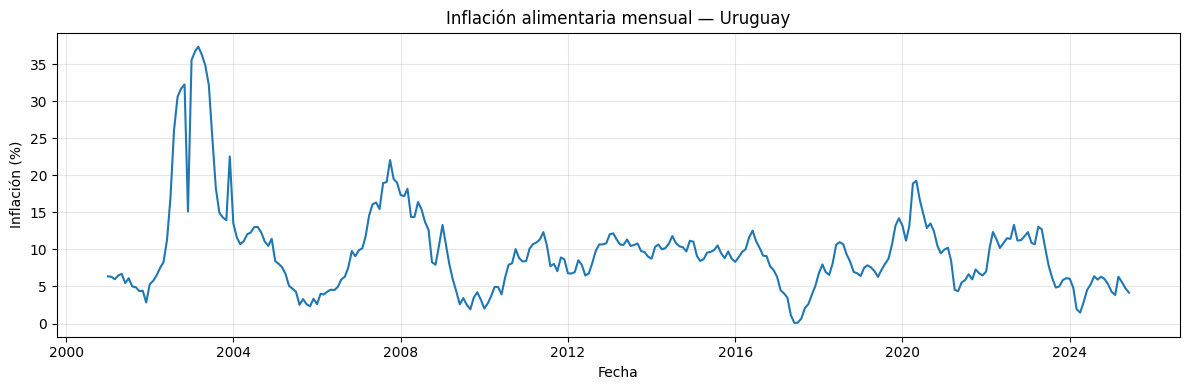

In [64]:
plot_country_inflation(df, "URY")

## Creación de features

El modelo recibe el par **(país, fecha)** más features temporales y predice la inflación de ese mes.

Features base:
- `country_enc` — país codificado numéricamente
- `year`, `month` — componentes temporales

Features de lag (valores históricos reales):
- `inflation_lag1/2/3/6/12` — inflación de meses anteriores
- `rolling_mean_3/12` — media móvil de los últimos 3 y 12 meses
- `yoy_change` — cambio interanual

Target: `inflation_log = log1p(clip(inflation, 0))` para reducir el impacto de outliers extremos.

In [65]:
le = LabelEncoder()
df["country_enc"] = le.fit_transform(df["country"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

# Lag features por país
for lag in [1, 2, 3, 6, 12]:
    df[f"inflation_lag{lag}"] = df.groupby("country")["inflation"].shift(lag)

# Rolling stats (shift(1) para no filtrar el valor actual)
df["rolling_mean_3"]  = df.groupby("country")["inflation"].transform(lambda x: x.shift(1).rolling(3).mean())
df["rolling_mean_12"] = df.groupby("country")["inflation"].transform(lambda x: x.shift(1).rolling(12).mean())
df["yoy_change"]      = df["inflation"] - df.groupby("country")["inflation"].shift(12)

# Log transform del target (clip para manejar valores negativos)
df["inflation_log"] = np.log1p(df["inflation"].clip(lower=0))

df = df.dropna().reset_index(drop=True)

FEATURE_COLS = [
    "country_enc", "year", "month",
    "inflation_lag1", "inflation_lag2", "inflation_lag3",
    "inflation_lag6", "inflation_lag12",
    "rolling_mean_3", "rolling_mean_12", "yoy_change"
]

print(f"Filas después de dropna: {len(df)}")
df[["country", "date", "inflation", "inflation_log"] + FEATURE_COLS].head()

Filas después de dropna: 57367


,country,date,inflation,inflation_log,country_enc,year,month,inflation_lag1,inflation_lag2,inflation_lag3,inflation_lag6,inflation_lag12,rolling_mean_3,rolling_mean_12,yoy_change
0,ABW,2002-01-01,4.087677,1.626821,0,2002,1,4.539627,4.446186,4.073828,3.672698,4.287808,4.353214,4.102221,-0.200131
1,ABW,2002-02-01,4.087414,1.626770,0,2002,2,4.087677,4.539627,4.446186,3.873451,4.425079,4.357830,4.085544,-0.337665
2,ABW,2002-03-01,3.857247,1.580472,0,2002,3,4.087414,4.087677,4.539627,3.870990,4.030159,4.238239,4.057405,-0.172912
3,ABW,2002-04-01,3.853137,1.579625,0,2002,4,3.857247,4.087414,4.087677,4.073828,4.056972,4.010779,4.042995,-0.203835
4,ABW,2002-05-01,4.013702,1.612175,0,2002,5,3.853137,3.857247,4.087414,4.446186,3.753138,3.932599,4.026009,0.260564


## Split temporal

Para series temporales el split debe ser **cronológico**, no aleatorio, para evitar filtrar datos futuros al entrenamiento.

- **Train**: todo antes del penúltimo año
- **Validación**: penúltimo año completo
- **Test**: último año completo (mide efectividad final del modelo)

In [66]:
split = train_val_test_split(df, FEATURE_COLS)
X_train, y_train = split.X_train, split.y_train
X_val,   y_val   = split.X_val,   split.y_val
X_test,  y_test  = split.X_test,  split.y_test
df_test = split.df_test
val_start, test_start     = split.val_start, split.test_start


Train:      2002-01-01 → 2023-06-01  (52767 obs)
Validación: 2023-07-01 → 2024-06-01  (2400 obs)
Test:       2024-07-01 → 2025-06-01  (2200 obs)


In [ ]:
wandb.init(
    project=WANDB_PROJECT,
    name="random-forest-v1",
    config={
        "n_estimators":      200,
        "max_depth":         10,
        "min_samples_split": 2,
        "min_samples_leaf":  5,
        "max_features":      "sqrt",
        "max_samples":       None,
        "bootstrap":         True,
        "oob_score":         True,
        "criterion":         "squared_error",
        "random_state":      42,
        "features":          FEATURE_COLS,
        "train_end":         str(val_start.date()),
        "val_end":           str(test_start.date()),
    }
)

In [90]:
model = RandomForestRegressor(
    n_estimators=wandb.config.n_estimators,
    max_depth=wandb.config.max_depth,
    min_samples_split=wandb.config.min_samples_split,
    min_samples_leaf=wandb.config.min_samples_leaf,
    max_features=wandb.config.max_features,
    max_samples=wandb.config.max_samples,
    bootstrap=wandb.config.bootstrap,
    oob_score=wandb.config.oob_score,
    criterion=wandb.config.criterion,
    random_state=wandb.config.random_state,
    n_jobs=-1
)

result       = train_and_evaluate(
    model, X_train, y_train, X_val, y_val, X_test, y_test,
    oob_score=wandb.config.oob_score,
)
test_metrics = result.test_metrics
mae          = result.mae
preds_test   = result.preds_test
y_test_orig  = result.y_test_orig
score        = result.score

--- Validación ---
  mae: 6.9247
  rmse: 29.3498
  r2: 0.1825
  acc_1pp: 0.3817
  acc_2pp: 0.6258
  acc_5pp: 0.8762
  oob_score: 0.7885

--- Test (último año) ---
  mae: 3.4178
  rmse: 15.3469
  r2: 0.3099
  acc_1pp: 0.5468
  acc_2pp: 0.7632
  acc_5pp: 0.9168


## Visualización: predicciones vs reales

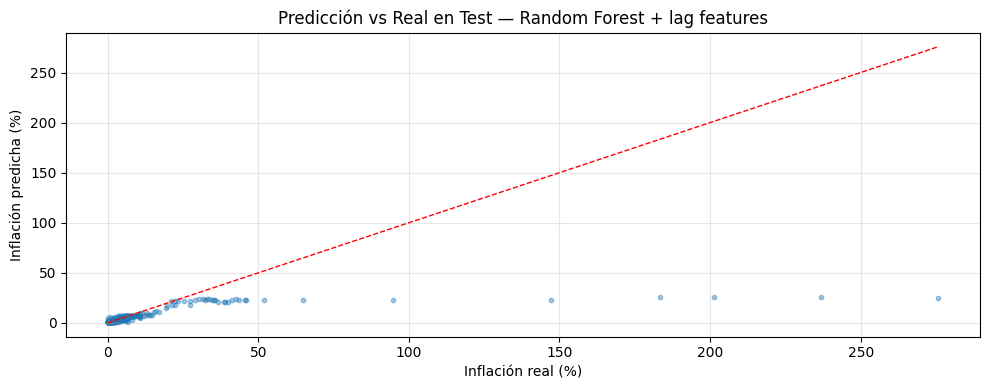

In [91]:
plot_pred_vs_real(
    y_test_orig, preds_test,
    title="Predicción vs Real en Test — Random Forest + lag features",
)

## Uruguay prediccion vs real

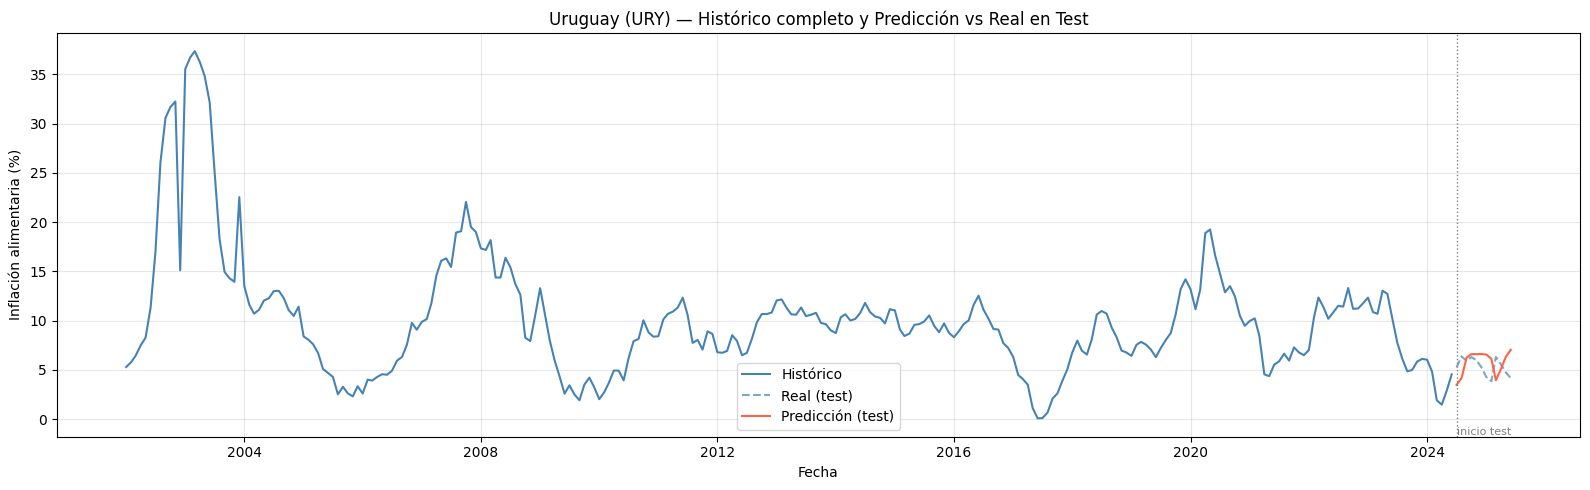

In [92]:
plot_country_test_predictions(
    df, model, df_test, test_start, FEATURE_COLS,
    country="URY", wandb_key="charts/uruguay_pred_vs_real",
)

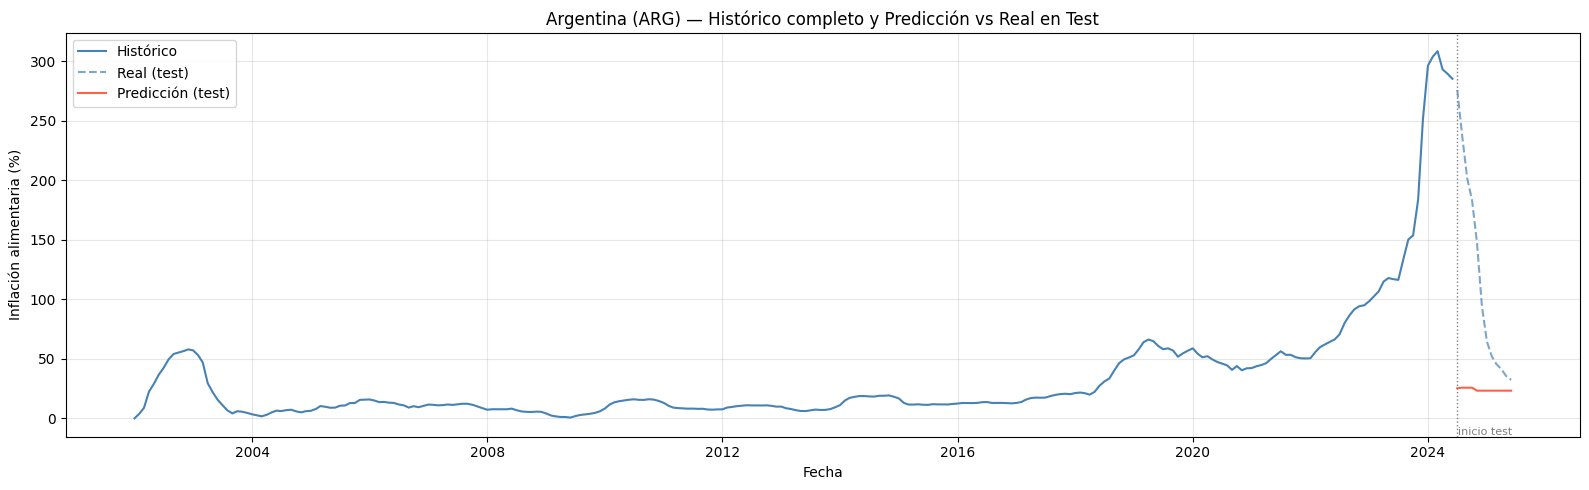

In [93]:
plot_country_test_predictions(
    df, model, df_test, test_start, FEATURE_COLS,
    country="ARG", wandb_key="charts/argentina_pred_vs_real",
)

## Predicción: próximos 12 meses para un país

Dado un país, generamos predicciones mes a mes para el año siguiente al último dato disponible.

In [94]:
predictor = FoodInflationPredictor.build(model, le, FEATURE_COLS, df)


def predict_next_12_months(country_code: str, predictor: FoodInflationPredictor) -> pd.DataFrame:
    if country_code not in predictor._le.classes_:
        raise ValueError(f"País '{country_code}' no está en el dataset")

    last_date    = predictor.last_date(country_code)
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

    rows = [{"date": d, "inflation_pred": predictor.predict(country_code, d.year, d.month)}
            for d in future_dates]
    return pd.DataFrame(rows)

In [95]:
COUNTRY = "URY"

forecast = predict_next_12_months(COUNTRY, predictor)
print(f"Predicciones para {COUNTRY} — próximos 12 meses:")
print(forecast.to_string(index=False))

Predicciones para URY — próximos 12 meses:
      date  inflation_pred
2025-07-01            5.99
2025-08-01            5.56
2025-09-01            6.19
2025-10-01            7.13
2025-11-01            7.01
2025-12-01            7.06
2026-01-01            7.05
2026-02-01            7.05
2026-03-01            7.19
2026-04-01            7.14
2026-05-01            7.11
2026-06-01            7.05


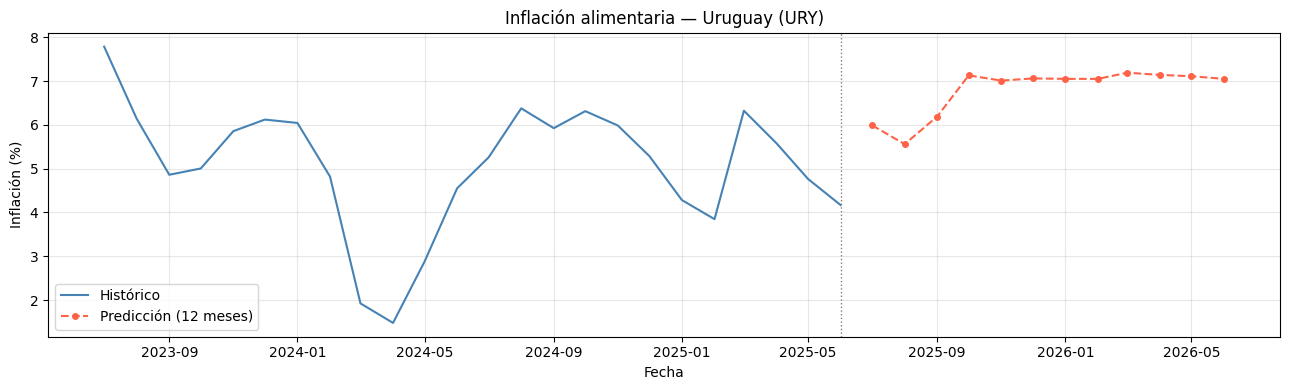

In [96]:
plot_country_forecast(
    df, forecast, country="URY", wandb_key="charts/forecast_ury",
)

In [97]:
# Comparar varios países
for code in ["ARG", "BRA", "URY", "USA"]:
    f = predict_next_12_months(code, predictor)
    nombre = df[df["country"] == code]["country_name"].iloc[0]
    print(f"\n{nombre} ({code}):")
    print(f"  Min: {f['inflation_pred'].min():.2f}%  |  Max: {f['inflation_pred'].max():.2f}%  |  Promedio: {f['inflation_pred'].mean():.2f}%")


Argentina (ARG):
  Min: 19.36%  |  Max: 23.29%  |  Promedio: 21.62%

Brazil (BRA):
  Min: 7.05%  |  Max: 7.19%  |  Promedio: 7.17%

Uruguay (URY):
  Min: 5.56%  |  Max: 7.19%  |  Promedio: 6.79%

United States (USA):
  Min: 2.39%  |  Max: 2.47%  |  Promedio: 2.44%


## Quality Gate

- Todo modelo se registra en **staging**.
- Solo si supera al mejor MAE histórico se promueve también a **production**.

In [98]:
promote_to_production = run_quality_gate(mae, WANDB_PROJECT)

[<Run marcos-mussio-org/food-inflation-forecasting/rx4e9d24 (finished)>, <Run marcos-mussio-org/food-inflation-forecasting/2mzw8cu9 (finished)>]
Best previous MAE: 1.3071837792146743
Current MAE: 3.4177709158345957
Promote to production: False


## Guardar modelo y métricas

In [99]:
metrics = {k: round(v, 4) for k, v in test_metrics.items()}
if wandb.config.oob_score:
    metrics["oob_score"] = round(score, 4)

aliases = register_model(
    predictor, WANDB_MODEL_NAME, metrics, promote_to_production,
    description="RandomForest para predicción de inflación alimentaria",
)
print(f"Artifact registrado con aliases: {aliases}")
wandb.finish()
print("Run de W&B finalizado")

Artifact registrado con aliases: ['staging', 'latest']


test/acc_1pp,▁
test/acc_2pp,▁
test/acc_5pp,▁
test/mae,▁
test/r2,▁
test/rmse,▁
val/acc_1pp,▁
val/acc_2pp,▁
val/acc_5pp,▁
val/mae,▁
+3,...


Run de W&B finalizado
